# Preguntas Clave 1-8

### 0. Preparando el entorno de trabajo


In [1]:
import pandas as pd
import matplotlib.pyplot as plt


df = pd.read_csv('../movies_2026.csv', encoding='latin-1')

### 1. Top 10 peliculas con presupuesto mas alto

In [2]:
df.sort_values(by='budget', ascending=False)[['title', 'budget']].head(10)

,title,budget
10606,Pirates of the Caribbean: On Stranger Tides,380000000.0
14600,Avengers: Age of Ultron,365000000.0
15842,Avengers: Endgame,356000000.0
5907,Avatar: Fire and Ash,350000000.0
10053,Pirates of the Caribbean: At World's End,300000000.0
15843,Avengers: Infinity War,300000000.0
14843,Justice League,300000000.0
10497,Superman Returns,270000000.0
13681,Tangled,260000000.0
17024,The Lion King,260000000.0


### Discusion Resultados
Podemos observar que las peliculas con mayor presupuesto son principalmente peliculas de franquisias populares, como las de Marvel, Piratas del Carive y Disney. Esto sugiere que las grandes producciones tienden a invertir mas en efectos especiales, actores reconocidos y marketing para atraer a una audiencia mas amplia.

### 2. Top 10 peliculas con mayor ingreso

In [10]:
# mayor ingreso 
df.sort_values(by='revenue', ascending=False)[['title', 'revenue', 'actorsAmount']].head(10)

,title,revenue,actorsAmount
13100,Avatar,2.847246e+09,37
15842,Avengers: Endgame,2.797801e+09,103
10197,Titanic,2.187464e+09,116
14837,Star Wars: The Force Awakens,2.068224e+09,188
15843,Avengers: Infinity War,2.046240e+09,65
8481,Zootopia 2,1.744338e+09,10
14804,Jurassic World,1.671713e+09,48
17024,The Lion King,1.667635e+09,20
18937,Spider-Man: No Way Home,1.631853e+09,59
13287,The Avengers,1.518816e+09,113


### Discusion Resultados
Al analizar las peliculas con mayores ingresos obtenidos, notamos que muchas de ellas son secuelas o parte también de franquisias muy grandes. Esto indica que las audiencias tienden a apoyar continuaciones de historias que ya conocen y disfrutan, lo que puede ser un factor clave para el éxito financiero de una pelicula. También hay que destacar que Avatar 1 siendo una pelicula innovadora en su momento, sin mucho presupuesto debido a que no aparece en el otro top 10 fue el mejor ingreso de todas las peliculas. 

### 3. Pelicula con mayor votos

In [9]:
## la top 1 pelicula con mayores votos
df.sort_values(by='voteCount', ascending=False)[['title', 'voteCount']].head(1)


,title,voteCount
13401,Inception,30788


### Discusion Resultados
Podemos observar que Inception es la peliucla con mas votos, indicando que tuvo un gran impacto para los espectadores. 

### 4. ¿Cuál es la peor película de acuerdo a los votos de todos los usuarios?

In [18]:
# Peor película solo considerando títulos con al menos un voto registrado
zero_vote_mask = df['voteCount'].fillna(0) == 0
print("Películas con 0 votos registrados:", zero_vote_mask.sum())

df_with_votes = df[~zero_vote_mask].copy()
worst_movies = df_with_votes.sort_values(by=['voteAvg', 'voteCount'], ascending=[True, True])
display(worst_movies[['title', 'voteAvg', 'voteCount']].head(20))

Películas con 0 votos registrados: 8302


,title,voteAvg,voteCount
1900,The Halloween Harvest,0.0,1
3536,The Cemetery of Sainte-Colombe,0.0,1
4268,Universe Designed,0.0,1
4648,The Man Downstairs,0.0,1
4875,Die Coen-BrÃ¼der - Eine amerikanische Geschichte,0.0,1
4997,A Christmas Murder Mystery,0.0,1
5025,The Don,0.0,1
5104,Speak to the Tide,0.0,1
5244,"Groenland, annexe-moi si tu peux",0.0,1
5248,MikoÅaj na sygnale 2: ZdÄ Å¼yÄ przed WigiliÄ,0.0,1


### Discusion Resultados
Tomamos en cuenta las peliculas que no tienen votos registrados, ya que en estas no se puede determinar una calificación y menos un promedio de votos. Por lo tanto las peliculas con promedio de votos mas bajo son las que solamente tienen votos mas bajos registrados. Esto sugiere que estas peliculas no lograron captar el interés de los espectadores o no cumplieron con sus expectativas, resultando en calificaciones negativas.

### 5. ¿Cuántas películas se hicieron en cada año? ¿En qué año se hicieron más películas? Haga un gráfico de barras

releaseYear
1902.0       1
1920.0       1
1921.0       1
1922.0       1
1925.0       2
          ... 
2020.0     531
2021.0     814
2022.0       7
2025.0    7351
2026.0    2537
Name: count, Length: 101, dtype: int64
Años donde mas peliculas se lanzaron: 2025.0


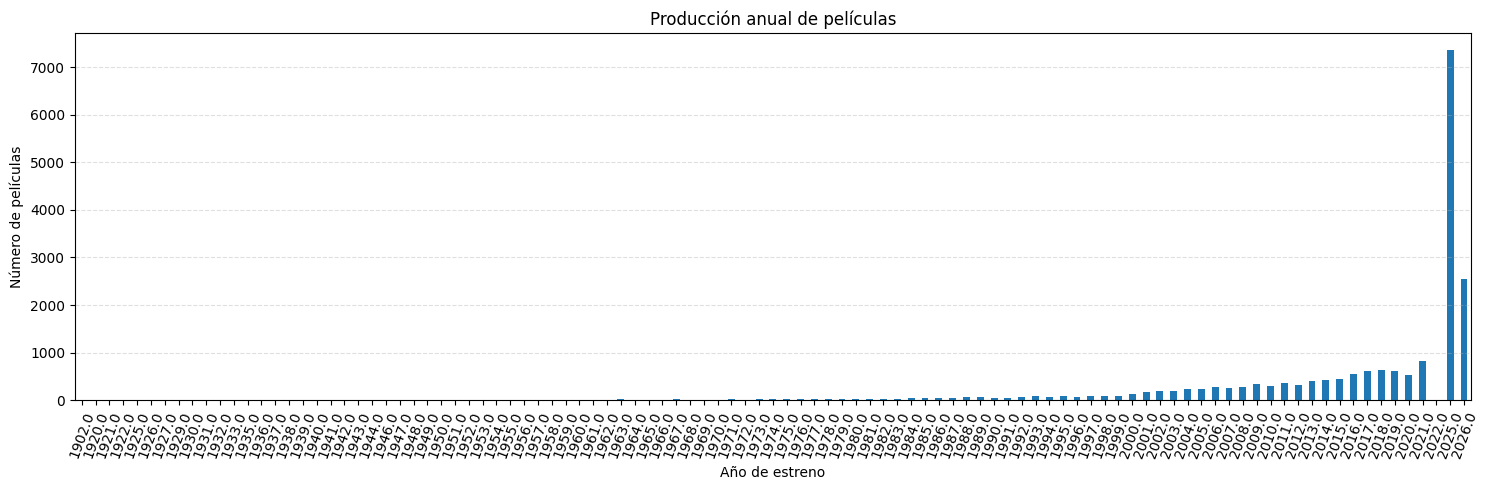

In [20]:
year_counts = df['releaseYear'].value_counts().sort_index()
print(year_counts)
print("Años donde mas peliculas se lanzaron:", year_counts.idxmax())

plt.figure(figsize=(15, 5))
year_counts.plot(kind='bar', color='#1f77b4')
plt.title('Producción anual de películas')
plt.xlabel('Año de estreno')
plt.ylabel('Número de películas')
plt.xticks(rotation=70)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

### Discusion Resultados
Analizando la cantidad de peliculas producidad por año, podemos notar que hubo un aumento significativo en la produccion de peliculas comenzando el año 2020. Esto sugiere que la industria cinematografica ha experimentado un crecimiento en la produccion de contenido, posiblemente impulsado por la demanda creciente de entretenimiento y la expansion de plataformas de streaming. Luego en los años 2025 y 2026 se observa el hit de s de 7000 peliculas producidas, lo que podria estar relacionado con avances tecnologicos que facilitan la produccion cinematografica o un aumento en la inversion en la industria del cine.

### 6. ¿Cuál es el género principal de las 20 películas más recientes? ¿Cuál es el género principal que predomina en el conjunto de datos? Represéntelo usando un gráfico.
#### 6.1. ¿A qué género principal pertenecen las películas más largas?

Genero de las 20 peliculas mas recientes: Documentary


,title,releaseDate,genres
488,A Fading Man,2026-05-07,Drama
7895,Elon Musk Unveiled â The Tesla Experiment,2026-03-12,Documentary
4054,Skunk,2026-02-25,NaN
4760,Anastasia,2026-02-25,NaN
6897,Nikki hako no koi,2026-02-06,NaN
0,Immersed,2026-02-01,Drama|Crime
44,You Just Watch & See,2026-02-01,NaN
49,Waves Turn,2026-02-01,Documentary
48,Three Ways of Returning,2026-02-01,NaN
47,AGOS-TONO,2026-02-01,Music|Mystery|Fantasy


Genero predominante en el dataset: Documentary


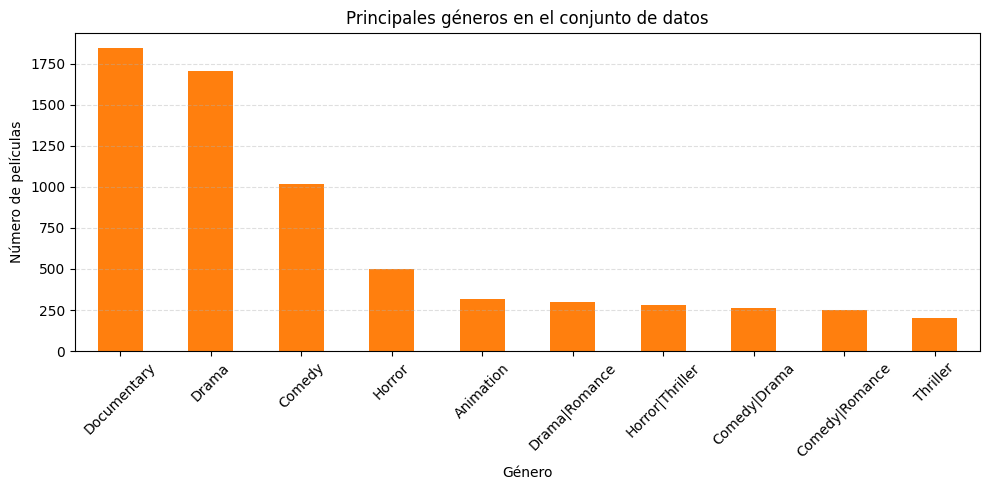

Genero predominante entre las peliculas mas largas: Documentary


,title,runtime,genres
19234,How Ponyo was Born ~Hayao Miyazaki's Thought P...,750,Documentary
3275,Before the End,675,Action|Drama|Romance
8933,League of Legends Worlds25 - Finals in Cinema,420,NaN
15248,Crystal Lake Memories: The Complete History of...,400,Documentary
3582,In Search of Darkness: 1995-1999,384,Documentary|Horror


In [23]:
# Género dominante entre las 20 películas más recientes
recent_movies = df.sort_values(by='releaseDate', ascending=False).head(20)
recent_mode = recent_movies['genres'].mode(dropna=True)
recent_genre = recent_mode.iloc[0] if not recent_mode.empty else 'Sin datos'
print("Genero de las 20 peliculas mas recientes:", recent_genre)
display(recent_movies[['title', 'releaseDate', 'genres']])

# Género predominante en todo el dataset y visualización de los 10 más frecuentes
genre_counts = df['genres'].value_counts(dropna=True)
dataset_genre = genre_counts.index[0] if not genre_counts.empty else 'Sin datos'
print("Genero predominante en el dataset:", dataset_genre)

plt.figure(figsize=(10, 5))
genre_counts.head(10).plot(kind='bar', color='#ff7f0e')
plt.title('Principales géneros en el conjunto de datos')
plt.xlabel('Género')
plt.ylabel('Número de películas')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# Género protagonista entre las películas con mayor duración
longest_movies = df.sort_values(by='runtime', ascending=False).head(20)
longest_mode = longest_movies['genres'].mode(dropna=True)
longest_genre = longest_mode.iloc[0] if not longest_mode.empty else 'Sin datos'
print("Genero predominante entre las peliculas mas largas:", longest_genre)
display(longest_movies[['title', 'runtime', 'genres']].head(5))

### Discusion Resultados

Es interesante ver como predominan los documentales, aunque sea el genero donde se encuentran las peliculas mas largas, lo que hace facilita la produccion de estas es que son basadas en hechos reales o se puede grabar con mayor facilidad ya que no hay que coordinar a un grupo tan grande de personas que trabajen en distintos ambitos, como los efectos especiales entre otros.


### 7. ¿A qué género principal pertenecen las películas más largas? 

In [8]:
print("Top 5 peliculas con mayor duracion:")
df.sort_values(by='runtime', ascending=False)[['title', 'runtime', 'genres']].head(5)

Top 5 peliculas con mayor duracion:


,title,runtime,genres
19234,How Ponyo was Born ~Hayao Miyazaki's Thought P...,750,Documentary
3275,Before the End,675,Action|Drama|Romance
8933,League of Legends Worlds25 - Finals in Cinema,420,NaN
15248,Crystal Lake Memories: The Complete History of...,400,Documentary
3582,In Search of Darkness: 1995-1999,384,Documentary|Horror


### Discusion Resultados
Las peliculas con mayor duracion tienden a pertenecer al genero de documentales, lo que sugiere que este tipo de peliculas a menudo requieren mas tiempo para explorar en profundidad sus temas y presentar informacion detallada. Esto puede deberse a la naturaleza informativa y educativa de los documentales, que a menudo buscan proporcionar una vision completa de un tema o historia.

### 7. ¿Las películas de qué genero principal obtuvieron mayores ganancias?

Género con mayor ingreso total: Action|Adventure|Science Fiction
Género con mayor ingreso promedio: Animation|Comedy|Adventure|Family|Mystery


,total_ingresos,ingreso_promedio,peliculas
genres,,,
Action|Adventure|Science Fiction,1.978039e+10,4.300085e+08,46
Comedy,1.708803e+10,1.681893e+07,1016
Comedy|Romance,1.377524e+10,5.510097e+07,250
Drama,1.278507e+10,7.498572e+06,1705
Action|Adventure|Fantasy,1.154096e+10,3.297416e+08,35
Adventure|Action|Science Fiction,1.001484e+10,7.153455e+08,14
Drama|Romance,9.704924e+09,3.224227e+07,301
Adventure|Fantasy|Action,8.191168e+09,4.550649e+08,18
Science Fiction|Action|Adventure,8.187441e+09,3.721564e+08,22


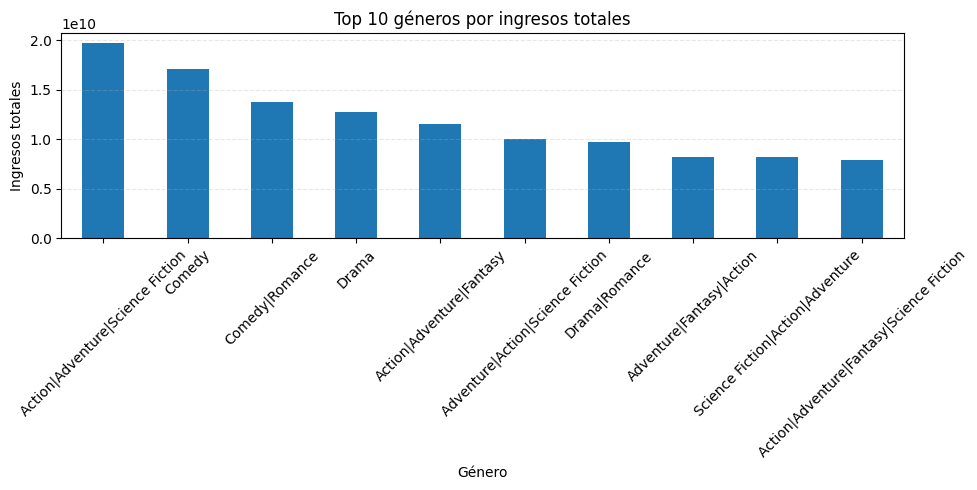

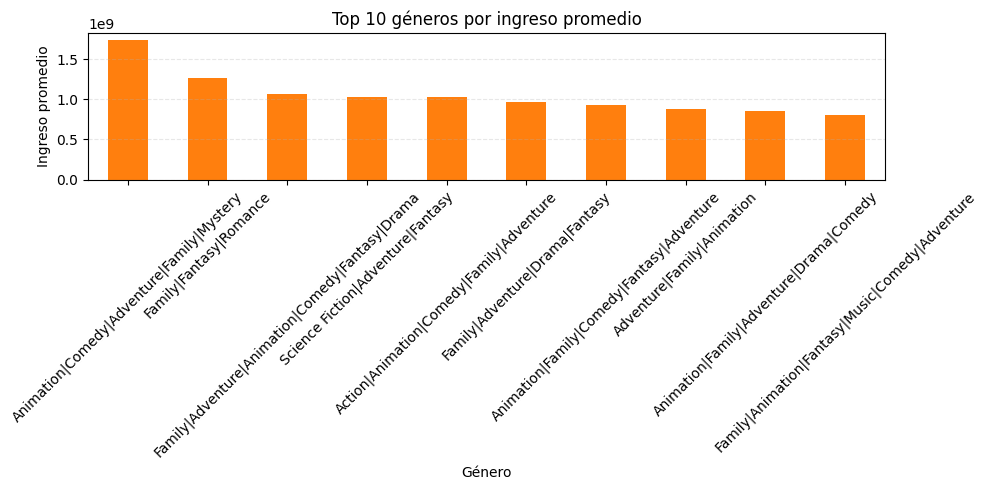

In [29]:
genre_revenue = (
    df.dropna(subset=['genres', 'revenue'])
      .groupby('genres')['revenue']
      .agg(total_ingresos='sum', ingreso_promedio='mean', peliculas='count')
      .sort_values('total_ingresos', ascending=False)
)

print("Género con mayor ingreso total:", genre_revenue.index[0])
print("Género con mayor ingreso promedio:", genre_revenue.sort_values('ingreso_promedio', ascending=False).index[0])

display(genre_revenue.head(10))

plt.figure(figsize=(10, 5))
genre_revenue.head(10)['total_ingresos'].plot(kind='bar', color='#1f77b4')
plt.title('Top 10 géneros por ingresos totales')
plt.xlabel('Género')
plt.ylabel('Ingresos totales')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
genre_revenue.sort_values('ingreso_promedio', ascending=False).head(10)['ingreso_promedio'].plot(kind='bar', color='#ff7f0e')
plt.title('Top 10 géneros por ingreso promedio')
plt.xlabel('Género')
plt.ylabel('Ingreso promedio')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

### Discusion Resultados
Las combinaciones de acción, aventura y ciencia ficción dominan los ingresos totales (≈19.8B USD), lo que confirma que los blockbusters de franquicia siguen impulsando la taquilla global. Sin embargo, cuando evaluamos el ingreso promedio por título, destacan géneros animados y familiares como por ejemplo Animation,Comedy,Adventure,Family,Mystery con >1.7B USD cada uno, lo que indica que estos estrenos monetizan mejor aunque sean menos frecuentes.Comparar ambas métricas muestra que los géneros masivos maximizan volumen, mientras que las propuestas familiares optimizan rentabilidad por proyecto; elegir una u otra estrategia depende de si se busca escalar o asegurar altos retornos por película.

### 8.  ¿La cantidad de actores influye en los ingresos de las películas? ¿se han hecho películas con más actores en los últimos años?

Correlation: -0.008392927923624368


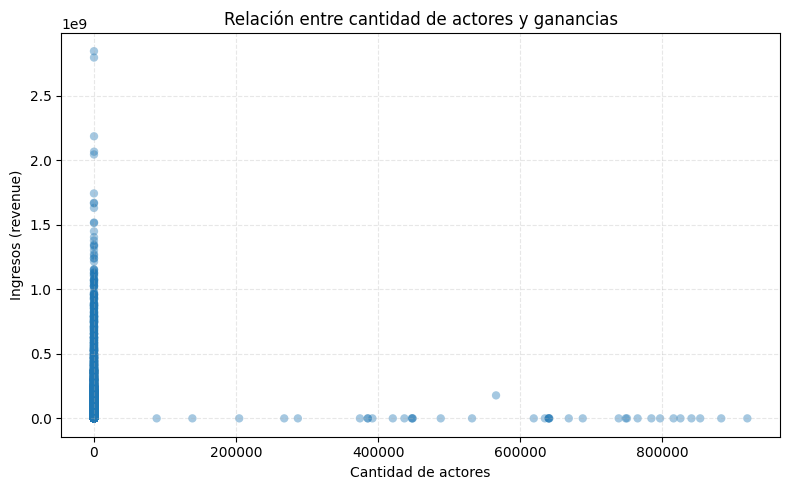

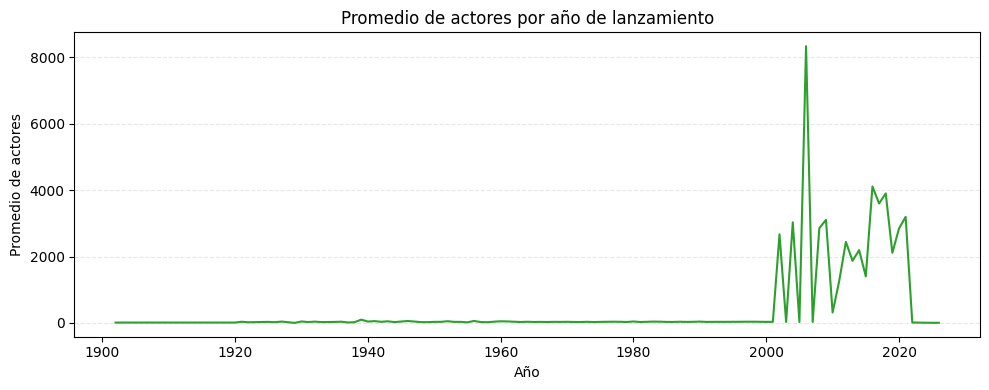

In [ ]:
data_q8 = df.dropna(subset=['actorsAmount', 'revenue', 'releaseYear'])
print("Correlation:", data_q8['actorsAmount'].corr(data_q8['revenue']))

plt.figure(figsize=(8, 5))
plt.scatter(data_q8['actorsAmount'], data_q8['revenue'], alpha=0.4, edgecolor='none')
plt.title('Relación entre cantidad de actores y ganancias')
plt.xlabel('Cantidad de actores')
plt.ylabel('Ingresos (revenue)')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
data_q8.groupby('releaseYear')['actorsAmount'].mean().plot(color='#2ca02c')
plt.title('Promedio de actores por año de lanzamiento')
plt.xlabel('Año')
plt.ylabel('Promedio de actores')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

### Discusion Resultados
La correlación casi nula (-0.008) confirma que sumar actores no garantiza mayores ingresos; la dispersión del scatter muestra títulos con elencos pequeños que logran taquillas enormes y superproducciones con muchas apariciones que recaudan poco.
El promedio de actores por año evidencia picos recientes, pero estos no se traducen en un crecimiento consistente de ingresos, así que inflar el elenco parece más una decisión creativa que financiera.
En conjunto, la evidencia sugiere que conviene enfocarse en calidad del reparto y propuesta diferencial antes que en la cantidad de actores cuando se busca maximizar la rentabilidad.